<a href="https://colab.research.google.com/github/25wh1a0564-ai/NASSCOM/blob/main/Week2/U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

# We use the built-in 'tips' dataset (no file upload needed).
# In your own work this would be: pd.read_csv('data.csv')
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
# -----------------------------------------------------------
# 🔹 1A. NUMERICAL vs CATEGORICAL COLUMNS
# -----------------------------------------------------------

# .dtypes tells you each column's type: float/int = numerical, object/category = categorical
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [3]:
# -----------------------------------------------------------
# 🔹 1B. WHICH STATISTIC FITS WHICH TYPE
# -----------------------------------------------------------

# Numerical -> mean / std make sense
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [15]:
# 1. Numerical vs categorical columns

numerical_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(include='object').columns

print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))


# 2. Mean of a numerical column (tip)

print("\nMean of tip:")
print(df["tip"].mean())


# 3. Value counts of a categorical column (sex)

print("\nValue Counts of sex:")
print(df["sex"].value_counts())

Numerical Columns:
['total_bill', 'tip', 'size']

Categorical Columns:
[]

Mean of tip:
2.99827868852459

Value Counts of sex:
sex
Male      157
Female     87
Name: count, dtype: int64


In [4]:
# -----------------------------------------------------------
# 🔹 2A. MEAN, MEDIAN, MODE
# -----------------------------------------------------------

col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value


Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


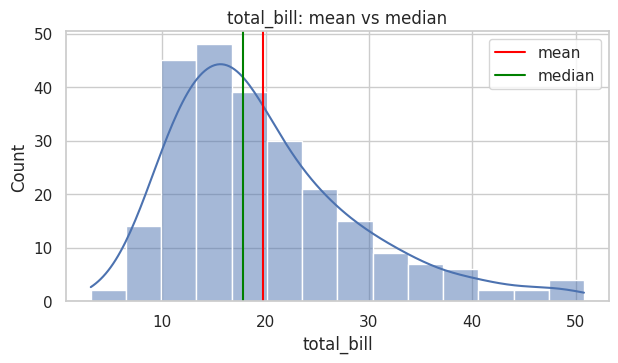

In [5]:
# -----------------------------------------------------------
# 🔹 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)
# -----------------------------------------------------------

# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean   : 2.99827868852459
Median : 2.9
Mode   : 2.0
The tip distribution is right-skewed.


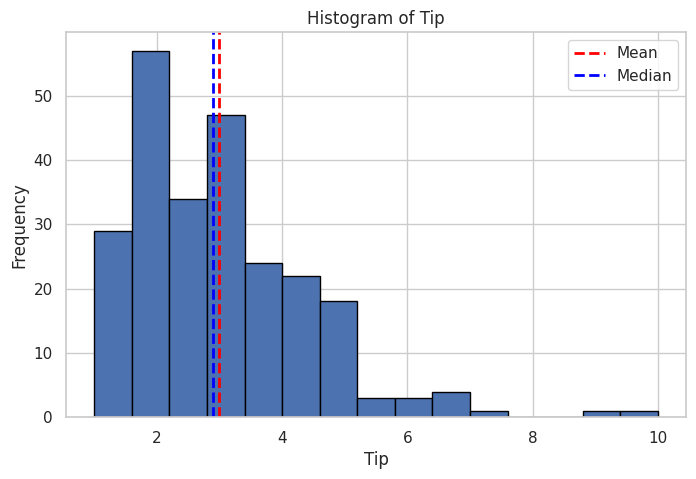

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Tip column
tip = df['tip']

# 1. Mean, Median, Mode
mean = tip.mean()
median = tip.median()
mode = tip.mode()[0]

print("Mean   :", mean)
print("Median :", median)
print("Mode   :", mode)

# 2. Check if mean > median
if mean > median:
    print("The tip distribution is right-skewed.")
else:
    print("The tip distribution is not right-skewed.")

# 3. Histogram with mean and median lines
plt.figure(figsize=(8,5))
plt.hist(tip, bins=15, edgecolor='black')

plt.axvline(mean, color='red', linestyle='--', linewidth=2, label='Mean')
plt.axvline(median, color='blue', linestyle='--', linewidth=2, label='Median')

plt.title("Histogram of Tip")
plt.xlabel("Tip")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [6]:
# -----------------------------------------------------------
# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION
# -----------------------------------------------------------

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))   # max - min
print('Var   :', round(col.var(), 2))                # variance (sigma^2)
print('Std   :', round(col.std(), 2))                # std deviation (sigma)

Range : 47.74
Var   : 79.25
Std   : 8.9


In [7]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [17]:
# Tip column
tip = df['tip']

# 1. Range, variance, standard deviation
range_value = tip.max() - tip.min()
variance = tip.var()
std = tip.std()

print("Range:", range_value)
print("Variance:", variance)
print("Standard Deviation:", std)

# 2. Q1, Q3, IQR
Q1 = tip.quantile(0.25)
Q3 = tip.quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

# 3. Most robust measure of spread
# IQR is the most robust measure of spread because it is less affected
# by outliers than range, variance, and standard deviation.

Range: 9.0
Variance: 1.9144546380624725
Standard Deviation: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625


In [8]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


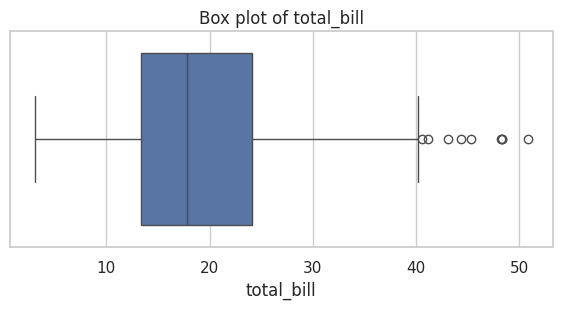

In [9]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

Five-number summary:
Minimum: 1.0
25% (Q1): 2.0
50% (Median): 2.9
75% (Q3): 3.5625
Maximum: 10.0

Skewness: 1.4654510370979401


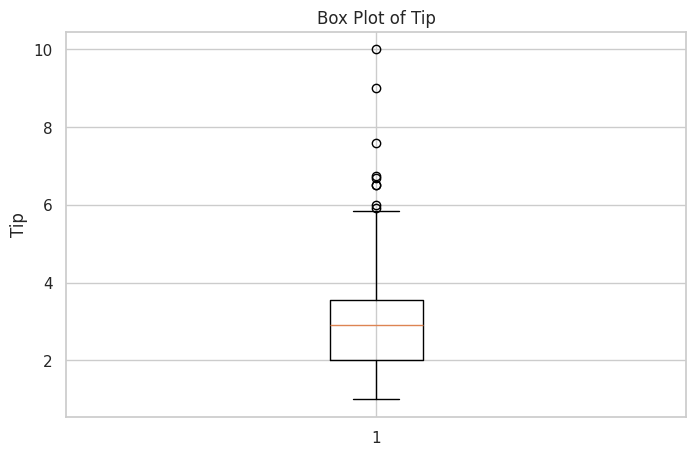

In [18]:
import matplotlib.pyplot as plt

tip = df['tip']

# 1. Five-number summary
five_number_summary = [
    tip.min(),
    tip.quantile(0.25),
    tip.median(),
    tip.quantile(0.75),
    tip.max()
]

print("Five-number summary:")
print("Minimum:", five_number_summary[0])
print("25% (Q1):", five_number_summary[1])
print("50% (Median):", five_number_summary[2])
print("75% (Q3):", five_number_summary[3])
print("Maximum:", five_number_summary[4])

# 2. Skewness (+ comment on the direction of the lean)
skewness = tip.skew()
print("\nSkewness:", skewness)

# Positive skewness means the distribution is right-skewed,
# so it has a longer tail toward higher tip values.

# 3. Box plot of tip
plt.figure(figsize=(8, 5))
plt.boxplot(tip)

plt.title("Box Plot of Tip")
plt.ylabel("Tip")
plt.show()

In [10]:
# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


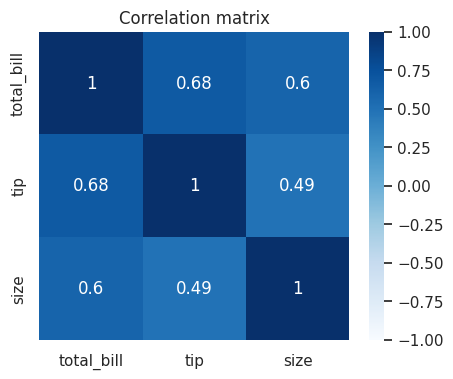

In [11]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [12]:
# -----------------------------------------------------------
# 🔹 5C. ONE-SHOT SUMMARY with .describe()
# -----------------------------------------------------------

# describe() returns count, mean, std, min, quartiles and max for every numeric column
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Dataset:
     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]

1. Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


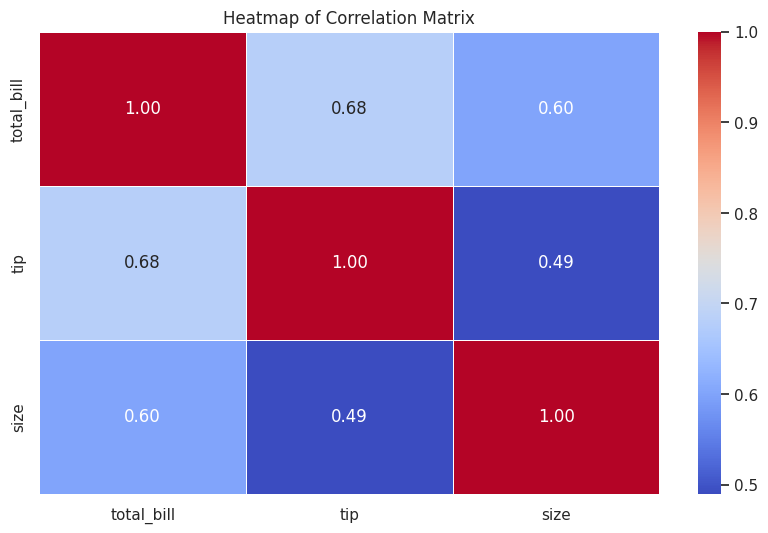


3. Descriptive Statistics:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Display the dataset
print("Dataset:")
print(df)

# 1. Correlation matrix (rounded)
print("\n1. Correlation Matrix:")
corr_matrix = df.corr(numeric_only=True).round(2)
print(corr_matrix)

# 2. Heatmap of the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Heatmap of Correlation Matrix")
plt.show()

# 3. Descriptive statistics
print("\n3. Descriptive Statistics:")
print(df.describe())